1. Clean raw data

In [1]:
import numpy as np
import pandas as pd
from Data.data_cleaning import Datacleaner

In [4]:
cleaner = Datacleaner("./Data/ligue1_2010_2025.csv")

cleaner = (cleaner.drop_useless_columns()
           .drop_rows(row_idxs=[1520,2607,2281])
           .fillNA(column='Div',value='F1')
           .fillNA(column='Time', value='00:00')
           .add_season())

cleaner.save_data("Data/Dataset_clean.csv")

c:\Leo_Perso\ENSAE\3A\Advanced ML\Projet ML\Learning-Latent-Football-Team-Strengths\Data\data_cleaning.py:26: DtypeWarning: Columns (139) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(filepath)


In [6]:
df = pd.read_csv("./Data/Dataset_clean.csv")

# Remove season 2025-2026 because incomplete
df = df[df['Season'] != '25-26']
df.to_csv("./Data/Dataset_clean_25.csv", index=False)


In [8]:
# Split the dataframe into train and test sets (last x rows for test)
n_total = len(df)

n_test = 306

train_df = df.iloc[:-n_test].copy()
test_df = df.iloc[-n_test:].copy()


# get data for train
teams = sorted(pd.unique(train_df[['HomeTeam','AwayTeam']].values.ravel()))

team_index ={team:i for i,team in enumerate(teams)}

n= len(teams)

# Victory Matrix
W = np.zeros((n,n), dtype=int)

# Draw Matrix
D = np.zeros((n,n), dtype=int)

for _,row in train_df.iterrows():

    i = team_index[row['HomeTeam']]
    j = team_index[row['AwayTeam']]

    if row['FTR'] == 'H':
        W[i,j] += 1
    elif row['FTR'] == 'A':
        W[j,i] += 1
    elif row['FTR'] == 'D':
        D[i,j] += 1
        D[j,i] += 1

train_data = {'Teams': teams,
                'Victory Matrix': W,
                'Draw Matrix': D}

W_matrix = train_data['Victory Matrix']
D_matrix = train_data['Draw Matrix']


Tolerance threshold attained after 234 iterations
Model fitted successfully !
Tolerance threshold attained after 236 iterations
Model fitted successfully !
Tolerance threshold attained after 237 iterations
Model fitted successfully !
Tolerance threshold attained after 239 iterations
Model fitted successfully !
Tolerance threshold attained after 241 iterations
Model fitted successfully !
Tolerance threshold attained after 244 iterations
Model fitted successfully !
Tolerance threshold attained after 247 iterations
Model fitted successfully !
Tolerance threshold attained after 251 iterations
Model fitted successfully !
Tolerance threshold attained after 255 iterations
Model fitted successfully !
Tolerance threshold attained after 260 iterations
Model fitted successfully !
Tolerance threshold attained after 266 iterations
Model fitted successfully !
Tolerance threshold attained after 273 iterations
Model fitted successfully !
Tolerance threshold attained after 282 iterations
Model fitted s

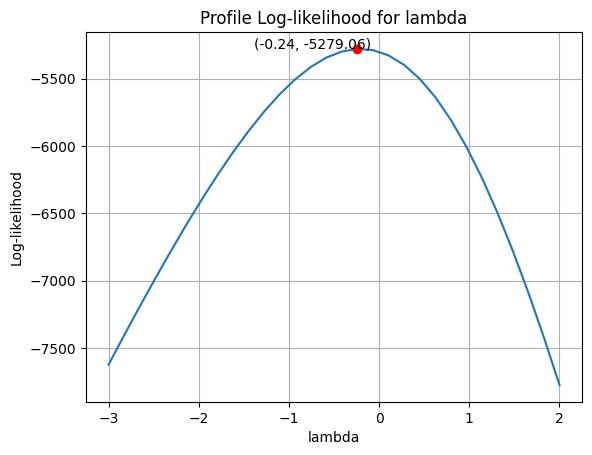

In [4]:
# Calibrate lambda

from BradleyTerry_classical.functions import BT_calibrate
from BradleyTerry_classical.BT_classical import BradleyTerry

Lambda_Chooser = BT_calibrate(W= W_matrix, D= D_matrix, teams= teams)

lambda_grid = np.linspace(-3,2,30)

Lambda_Chooser.calibrate_lambda(lambda_grid=lambda_grid)


In [9]:
# Train the model
from BradleyTerry_classical.BT_classical import BradleyTerry

bt_model = BradleyTerry(lambda_draw=-0.24, learning_rate=0.01, n_iterations=1000)
bt_model.fit(W=W_matrix, D=D_matrix, teams=teams)

strength = bt_model.predict_strength()

Tolerance threshold attained after 333 iterations
Model fitted successfully !


In [11]:
df_BT = strength.copy()
df_BT

,Team,Strength
0,Ajaccio,-0.715132
1,Ajaccio GFCO,-0.408636
2,Amiens,-0.353454
3,Angers,-0.217858
4,Arles,-1.494393
5,Auxerre,-0.309198
6,Bastia,-0.099556
7,Bordeaux,0.278030
8,Brest,-0.074030
9,Caen,-0.269808


In [12]:
from Neural_Bradley_Terry.NeuralBT import NeuralBradleyTerry
import torch

# ==============================================================================
# 2. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ==============================================================================
# On charge le fichier final créé précédemment
df = pd.read_csv("Data/dataset_final_training.csv")

# Liste des features (Assurez-vous que ces colonnes existent dans votre CSV)
# Note : on utilise les noms de base, on rajoutera _Home et _Away après
feature_names = [
    'Log_Market_Value',      # Structurel
    'Strength_Rank_Based',   # Historique
    'Pythagorean_Exp',       # Forme théorique
    'Avg_Goals_Scored',      # Attaque
    'Home_Dependency'        # Domicile
]

# Création des matrices X_home, X_away et y
# On prend toutes les données (Train + Test mélangés pour cet exemple simple)
X_home = df[[f"{col}_Home" for col in feature_names]].values.astype(np.float32)
X_away = df[[f"{col}_Away" for col in feature_names]].values.astype(np.float32)
y = df['Target'].values.astype(np.float32)

# ==============================================================================
# 3. ENTRAÎNEMENT
# ==============================================================================
model = NeuralBradleyTerry(input_dim=len(feature_names))
model.fit(X_home, X_away, y, epochs=500)

# ==============================================================================
# 4. OBTENIR LES FORCES (Ce que vous demandez)
# ==============================================================================

def get_season_ranking(model, df_full, target_season, feature_cols):
    """
    Extrait les forces des équipes pour une saison précise.
    """
    # 1. On filtre pour garder une seule ligne par équipe pour cette saison
    # On utilise les infos "Home" pour avoir les stats de l'équipe
    unique_teams = df_full[df_full['Season'] == target_season].drop_duplicates(subset=['HomeTeam'])
    
    if unique_teams.empty:
        print(f"Aucune donnée trouvée pour la saison {target_season}")
        return None

    # 2. Préparation des features de ces équipes
    cols_home = [f"{col}_Home" for col in feature_cols]
    X_teams = unique_teams[cols_home].values.astype(np.float32)

    # 3. Le modèle prédit la force !
    model.eval()
    with torch.no_grad():
        strengths = model.forward(torch.tensor(X_teams)).numpy().flatten()
        
        strengths = strengths - np.mean(strengths)  # Centrage pour interprétation relative

        print(f"Moyennes des forces {np.mean(strengths)}")
    
    # 4. Création du tableau de résultat
    ranking = pd.DataFrame({
        'Team': unique_teams['HomeTeam'],
        'Neural_Strength': strengths
        })
    
        # On trie du plus fort au plus faible
    return ranking.sort_values(by='Neural_Strength', ascending=False)

# --- EXEMPLE : CLASSEMENT POUR LA DERNIÈRE SAISON DU FICHIER ---
last_season = '2024-2025' # Ex: "22-23" ou "2022" selon votre format
print(f"\n--- CLASSEMENT NEURAL POUR LA SAISON {last_season} ---")

ranking = get_season_ranking(model, df, last_season, feature_names)

ranking

Début de l'entraînement...
Epoch 0 | Loss: 0.6892
Epoch 50 | Loss: 0.6778
Epoch 100 | Loss: 0.6777
Epoch 150 | Loss: 0.6777
Epoch 200 | Loss: 0.6777
Epoch 250 | Loss: 0.6777
Epoch 300 | Loss: 0.6777
Epoch 350 | Loss: 0.6777
Epoch 400 | Loss: 0.6777
Epoch 450 | Loss: 0.6777
Entraînement terminé.

--- CLASSEMENT NEURAL POUR LA SAISON 2024-2025 ---
Moyennes des forces -6.622738357719982e-09


,Team,Neural_Strength
5153,Paris SG,0.881673
5147,Monaco,0.551999
5145,Brest,0.350168
5155,Lille,0.223862
5152,Rennes,0.140945
5159,Nice,0.094078
5154,Lyon,0.060773
5151,Toulouse,0.045854
5157,Lens,0.042397
5161,Marseille,0.037829


In [13]:
from Test.test_BT_classical import BT_evaluate_strengths

b = BT_evaluate_strengths(BT_results=df_BT, NBTR_results=ranking, test_df=test_df)

b.calculate_performance_metrics()

b.performance_metrics

,Team,Points,WinRate,WinRateAdj
0,Paris SG,84.0,0.764706,0.852941
1,Marseille,65.0,0.588235,0.661765
2,Monaco,61.0,0.529412,0.632353
3,Nice,60.0,0.500000,0.632353
4,Lille,60.0,0.500000,0.632353
5,Lyon,57.0,0.500000,0.588235
6,Strasbourg,57.0,0.470588,0.602941
7,Lens,52.0,0.441176,0.544118
8,Brest,50.0,0.441176,0.514706
9,Auxerre,42.0,0.323529,0.455882


In [14]:
b.results_correlation(model='BT',metric='rank')

{'correlation': np.float64(0.6390913358878553),
 'pvalue': np.float64(0.004299097971605389),
 'ci_lower': np.float64(0.17831061815098986),
 'ci_upper': np.float64(0.8810925573973661)}

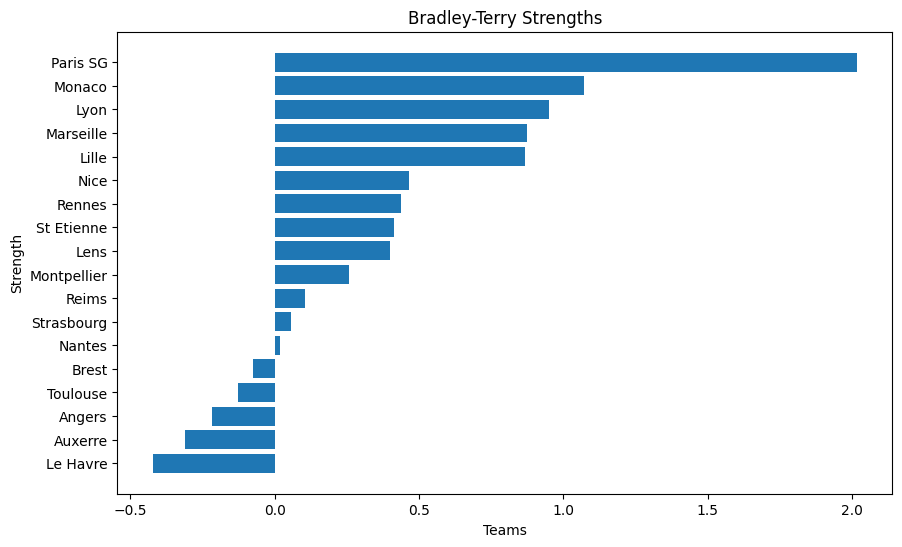

In [15]:
b.plot_strengths(model='BT')